# Análisis de Defunciones Registradas - INEGI 2000
### Universidad de Guadalajara — CUCEA
### Maestría en Ciencia de Datos (MCD)
### Materia: Programación II
### Alumno: Carlos Pulido Rosas

---

Este notebook aplica las bibliotecas **PySpark**, **PyODBC**, **NumPy**, **Pandas**, **rpy2** y **Scikit-learn** para analizar la base de datos del Censo de Defunciones Registradas del INEGI (2000), con más de 10 millones de registros almacenados en **SQL Server**.

**Pipeline de datos:**
```
SQL Server (Defunciones_2000) → Pandas → NumPy → Scikit-learn → Resultados
```

## 0. Conexión a SQL Server
Usamos `pyodbc` para conectarnos directamente a la base de datos `Defunciones_2000` y consumir las vistas ya creadas, evitando cargar los 10 millones de registros completos en memoria.

In [1]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyodbc
import warnings
import os
warnings.filterwarnings('ignore')

# Conexión a SQL Server
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=localhost;'
    'DATABASE=Defunciones_2000;'
    'Trusted_Connection=yes;'
)

print('Conexion a SQL Server exitosa')
print('Base de datos: Defunciones_2000')
print('Servidor: localhost')


# Cargar variables de entorno
load_dotenv()
jdbc_url = f"jdbc:sqlserver://{os.getenv('DB_SERVER')}:1433;databaseName={os.getenv('DB_NAME')};encrypt=false;trustServerCertificate=true"
print(f'Conectando a {os.getenv("DB_NAME")} en {os.getenv("DB_SERVER")}')




Conexion a SQL Server exitosa
Base de datos: Defunciones_2000
Servidor: localhost
Conectando a Defunciones_2000 en localhost


In [2]:
# Verificar que tenemos spark conectado
import findspark
findspark.init()

from pyspark.sql import SparkSession
import time

# Iniciar Spark con el driver JDBC
spark = SparkSession.builder \
    .appName("Censo2000") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.extraClassPath", "C:\\spark\\jars\\mssql-jdbc-13.4.0.jre11.jar") \
    .config("spark.executor.extraClassPath", "C:\\spark\\jars\\mssql-jdbc-13.4.0.jre11.jar") \
    .getOrCreate()

print(f'Spark version: {spark.version}')

Spark version: 3.5.6


## 1. Carga de datos

El análisis inicia con la carga de datos desde SQL Server. Durante el desarrollo
se identificaron dos limitaciones importantes al usar Pandas con la tabla principal
de 17 millones de registros:

1. **Memoria insuficiente**: Pandas carga todos los datos en RAM, lo que provocó
   errores de memoria al intentar procesar la tabla completa de defunciones.
2. **Tiempos de espera**: Consultas simples tardaban entre 8 y 10 minutos debido
   al volumen de datos.

Para resolver esto se implementaron dos estrategias:

**Estrategia 1 — Tablas materializadas con Pandas**
Para el análisis descriptivo se crearon tablas resumidas en SQL Server con los
datos ya agregados. Pandas los carga en menos de 1 segundo al ser tablas pequeñas.

| Tabla | Descripción | Registros |
|-------|-------------|-----------|
| `tbl_kpis` | Indicadores generales de cobertura | 1 |
| `tbl_acceso_resumen` | Distribución por tipo de servicio | 3 |
| `tbl_estados_resumen` | Cobertura agregada por estado | 32 |
| `tbl_urbano_resumen` | Cobertura urbano vs rural | 7 |
| `tbl_escolaridad_resumen` | Cobertura por nivel educativo | 11 |
| `tbl_indigena_resumen` | Cobertura población indígena | 6 |

**Estrategia 2 — Apache Spark para la tabla completa**
Para el modelado predictivo que requiere los 17 millones de registros individuales,
se utiliza Apache Spark (PySpark). A diferencia de Pandas, Spark procesa los datos
de forma distribuida sin necesidad de cargarlos completamente en RAM, lo que permite
trabajar con volumenes de datos que superan la memoria disponible del sistema.

In [6]:
from dotenv import load_dotenv
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
import time

# Cargar variables de entorno
load_dotenv()

DB_USER   = os.getenv('DB_USER')
DB_PASS   = os.getenv('DB_PASSWORD')
DB_SERVER = os.getenv('DB_SERVER')
DB_NAME   = os.getenv('DB_NAME')

# Detener sesion anterior si existe
try:
    spark.stop()
except:
    pass

# Iniciar Spark con el driver JDBC
spark = SparkSession.builder \
    .appName("Censo2000") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.extraClassPath", "C:\\spark\\jars\\mssql-jdbc-13.4.0.jre11.jar") \
    .config("spark.executor.extraClassPath", "C:\\spark\\jars\\mssql-jdbc-13.4.0.jre11.jar") \
    .getOrCreate()

print(f'Spark iniciado correctamente')
print(f'Version: {spark.version}')
print(f'Conectando a {DB_NAME} en {DB_SERVER}')

# URL de conexion
jdbc_url = f"jdbc:sqlserver://{DB_SERVER}:1433;databaseName={DB_NAME};encrypt=false;trustServerCertificate=true"

# Funcion para cargar tablas
def cargar_tabla(tabla, descripcion):
    inicio = time.time()
    df = spark.read \
        .format("jdbc") \
        .option("url", jdbc_url) \
        .option("dbtable", tabla) \
        .option("user", DB_USER) \
        .option("password", DB_PASS) \
        .option("driver", "com.microsoft.sqlserver.jdbc.SQLServerDriver") \
        .load()
    tiempo = time.time() - inicio
    print(f'{descripcion}: {df.count():,} registros en {tiempo:.1f}s')
    return df

# Cargar tablas materializadas
df_kpis        = cargar_tabla("tbl_kpis", "KPIs")
df_acceso      = cargar_tabla("tbl_acceso_resumen", "Acceso salud")
df_estados     = cargar_tabla("tbl_estados_resumen", "Estados")
df_urbano      = cargar_tabla("tbl_urbano_resumen", "Urbano Rural")
df_escolaridad = cargar_tabla("tbl_escolaridad_resumen", "Escolaridad")
df_indigena    = cargar_tabla("tbl_indigena_resumen", "Indigena")

# Cargar tabla completa para el modelo
print('\nCargando tabla completa de defunciones...')
df_defunciones = cargar_tabla("defunciones", "Defunciones")

Spark iniciado correctamente
Version: 3.5.6
Conectando a Defunciones_2000 en localhost
KPIs: 1 registros en 0.3s
Acceso salud: 3 registros en 0.3s
Estados: 32 registros en 0.2s
Urbano Rural: 7 registros en 0.2s
Escolaridad: 11 registros en 0.2s
Indigena: 6 registros en 0.2s

Cargando tabla completa de defunciones...
Defunciones: 10,099,182 registros en 0.3s


## 2. Análisis estadístico con NumPy

NumPy permite realizar operaciones matemáticas vectorizadas sobre grandes volúmenes 
de datos de manera eficiente. En este análisis se aplica sobre las tablas 
materializadas cargadas desde SQL Server para calcular estadísticas de acceso 
a salud, brecha urbano-rural y visualizar la narrativa completa del censo 2000.

**Análisis realizados:**
- Distribución porcentual de acceso a servicios de salud por tipo
- Brecha de cobertura entre zonas rurales, semirurales, urbanas y metropolitanas
- Visualización comparativa de los cuatro hallazgos principales del censo

In [8]:
# Convertir de Spark a pandas para NumPy
df_acceso_pd = df_acceso.toPandas()
df_urbano_pd = df_urbano.toPandas()
df_escolaridad_pd = df_escolaridad.toPandas()
df_estados_pd = df_estados.toPandas()
df_kpis_pd = df_kpis.toPandas()
df_indigena_pd = df_indigena.toPandas()

print('DataFrames convertidos a pandas correctamente')

# Estadisticas de acceso a salud con NumPy
totales = np.array(df_acceso_pd['total'])
servicios = np.array(df_acceso_pd['tipo_servicio'])

total_pob = np.sum(totales)
print('--- Estadisticas con NumPy ---')
for servicio, total in zip(servicios, totales):
    print(f'{servicio:<25}: {total:>10,} ({total/total_pob*100:.2f}%)')

print(f'\nTotal poblacion          : {total_pob:,}')
print(f'Media por categoria      : {np.mean(totales):,.2f}')
print(f'Desviacion estandar      : {np.std(totales):,.2f}')

DataFrames convertidos a pandas correctamente
--- Estadisticas con NumPy ---
Otro                     :    803,623 (7.96%)
Sin derechohabiencia     :  6,631,705 (65.67%)
IMSS                     :  2,663,854 (26.38%)

Total poblacion          : 10,099,182
Media por categoria      : 3,366,394.00
Desviacion estandar      : 2,430,611.28


In [9]:
# Análisis urbano vs rural con NumPy
df_urbano_filtrado = df_urbano_pd[~df_urbano_pd['tipo_localidad'].str.contains('No especificado')].copy()

con_imss_urbano = np.array(df_urbano_filtrado['con_imss'])
sin_derecho_urbano = np.array(df_urbano_filtrado['sin_derechohabiencia'])
total_urbano = np.array(df_urbano_filtrado['total'])

print('--- Brecha Urbano vs Rural ---')
for i, localidad in enumerate(df_urbano_filtrado['tipo_localidad']):
    cobertura = con_imss_urbano[i] / total_urbano[i] * 100
    sin_cob = sin_derecho_urbano[i] / total_urbano[i] * 100
    print(f'{localidad:<30}: Cobertura {cobertura:.1f}% | Sin cobertura {sin_cob:.1f}%')

--- Brecha Urbano vs Rural ---
Urbano (15,000-99,999)        : Cobertura 31.3% | Sin cobertura 59.0%
Semirural (2,500-14,999)      : Cobertura 20.5% | Sin cobertura 71.5%
Rural (menos 2,500)           : Cobertura 12.3% | Sin cobertura 83.7%
Metropolitano (100,000+)      : Cobertura 30.5% | Sin cobertura 58.7%


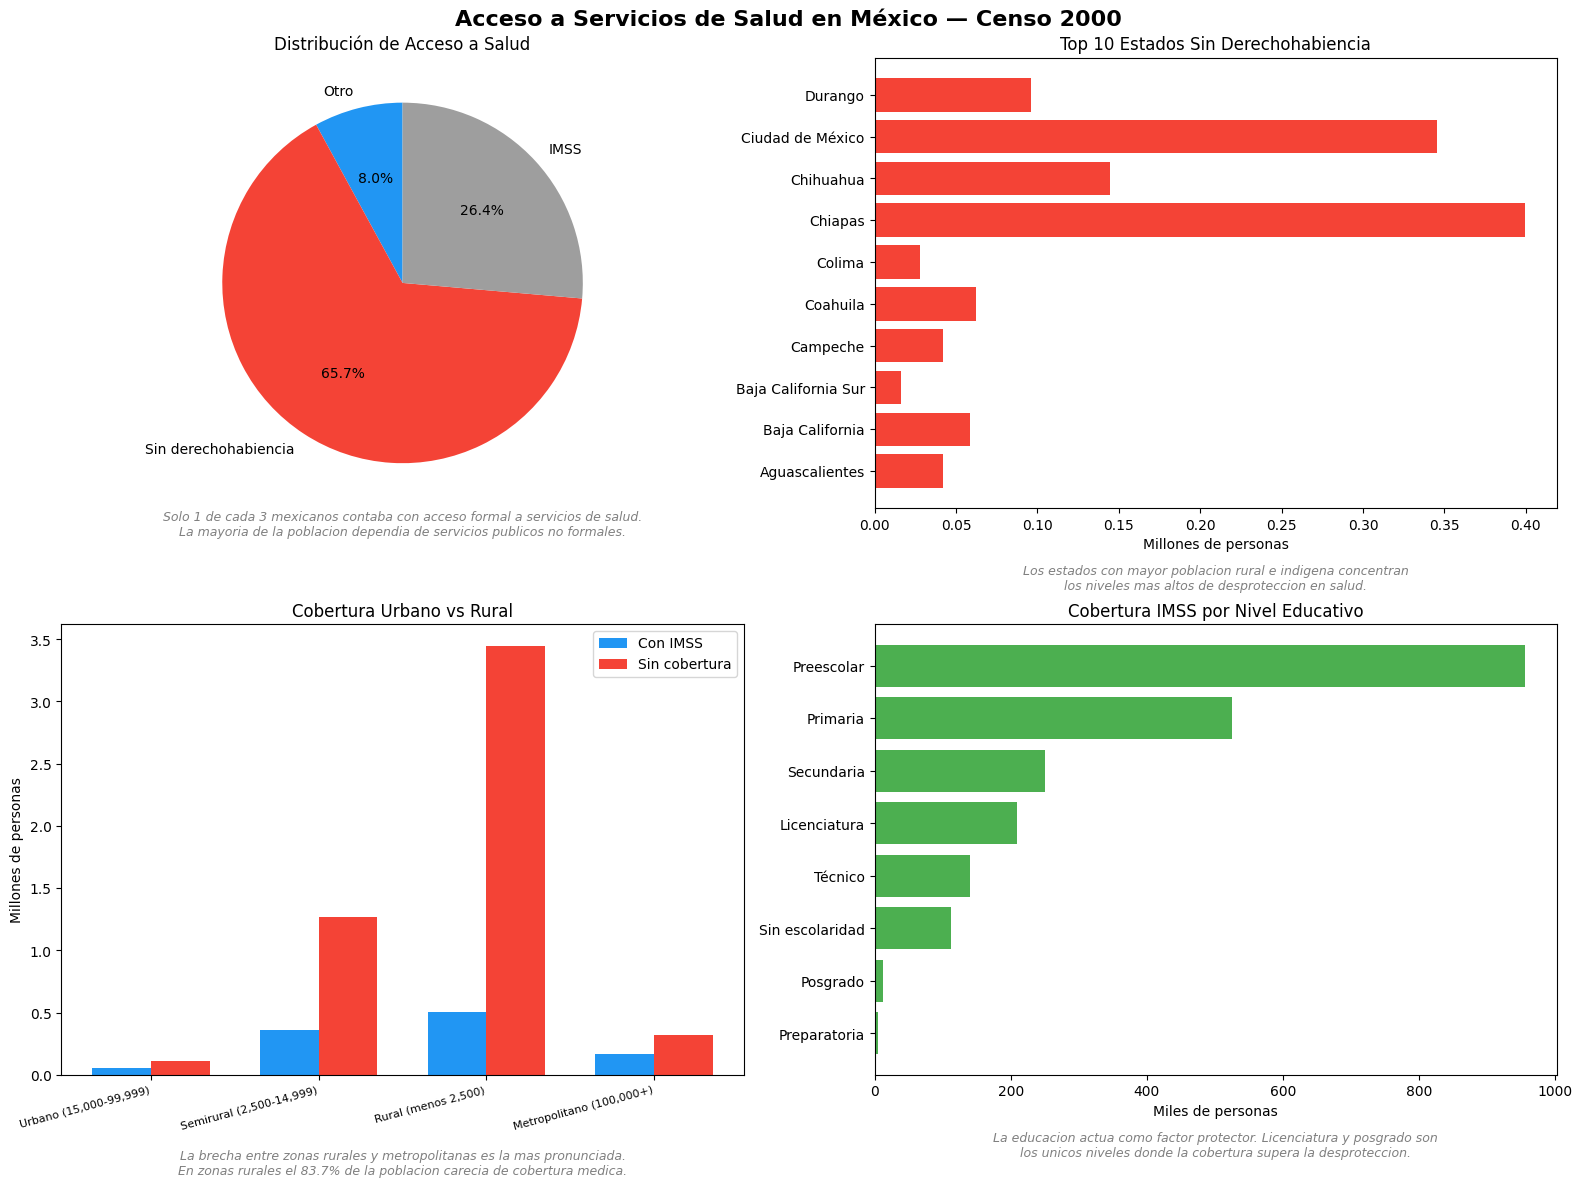

Grafica guardada como narrativa_salud_2000.png


In [10]:
# Visualizaciones de la narrativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Acceso a Servicios de Salud en México — Censo 2000', fontsize=16, fontweight='bold')

# 1. Pie chart - acceso general
colores = ['#2196F3', '#F44336', '#9E9E9E']
axes[0,0].pie(df_acceso_pd['total'], labels=df_acceso_pd['tipo_servicio'],
              colors=colores, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribución de Acceso a Salud', fontsize=12)
axes[0,0].text(0, -1.4,
    'Solo 1 de cada 3 mexicanos contaba con acceso formal a servicios de salud.\n'
    'La mayoria de la poblacion dependia de servicios publicos no formales.',
    ha='center', fontsize=9, color='gray', style='italic')

# 2. Barras - top 10 estados sin cobertura
top10 = df_estados_pd.head(10)
axes[0,1].barh(top10['nombre_estado'], top10['sin_derechohabiencia']/1e6, color='#F44336')
axes[0,1].set_title('Top 10 Estados Sin Derechohabiencia', fontsize=12)
axes[0,1].set_xlabel('Millones de personas')
axes[0,1].text(0.5, -0.18,
    'Los estados con mayor poblacion rural e indigena concentran\n'
    'los niveles mas altos de desproteccion en salud.',
    transform=axes[0,1].transAxes, ha='center', fontsize=9, color='gray', style='italic')

# 3. Barras agrupadas - urbano vs rural
x = np.arange(len(df_urbano_filtrado['tipo_localidad']))
width = 0.35
axes[1,0].bar(x - width/2, df_urbano_filtrado['con_imss']/1e6, width, label='Con IMSS', color='#2196F3')
axes[1,0].bar(x + width/2, df_urbano_filtrado['sin_derechohabiencia']/1e6, width, label='Sin cobertura', color='#F44336')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(df_urbano_filtrado['tipo_localidad'], rotation=15, ha='right', fontsize=8)
axes[1,0].set_title('Cobertura Urbano vs Rural', fontsize=12)
axes[1,0].set_ylabel('Millones de personas')
axes[1,0].legend()
axes[1,0].text(0.5, -0.22,
    'La brecha entre zonas rurales y metropolitanas es la mas pronunciada.\n'
    'En zonas rurales el 83.7% de la poblacion carecia de cobertura medica.',
    transform=axes[1,0].transAxes, ha='center', fontsize=9, color='gray', style='italic')

# 4. Barras - escolaridad vs cobertura
df_esc_valid = df_escolaridad_pd[df_escolaridad_pd['nivel_educativo'] != 'No especificado'].copy()
df_esc_valid = df_esc_valid.sort_values('con_imss', ascending=True)
axes[1,1].barh(df_esc_valid['nivel_educativo'], df_esc_valid['con_imss']/1e3, color='#4CAF50')
axes[1,1].set_title('Cobertura IMSS por Nivel Educativo', fontsize=12)
axes[1,1].set_xlabel('Miles de personas')
axes[1,1].text(0.5, -0.18,
    'La educacion actua como factor protector. Licenciatura y posgrado son\n'
    'los unicos niveles donde la cobertura supera la desproteccion.',
    transform=axes[1,1].transAxes, ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('narrativa_salud_2000.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada como narrativa_salud_2000.png')

## 3. Análisis estadístico con rpy2

rpy2 es una biblioteca que permite integrar el lenguaje R dentro de Python, 
aprovechando las herramientas estadísticas avanzadas de R sin salir del entorno 
de Python. R es ampliamente utilizado en epidemiología, salud pública y análisis 
demográfico por su robustez estadística.

En este análisis se utiliza rpy2 para ejecutar una prueba chi-cuadrado sobre 
la distribución de derechohabiencia en la población mexicana del año 2000, 
determinando si la distribución observada es estadísticamente diferente 
de una distribución uniforme esperada.

**Prueba realizada:**
- Chi-cuadrado de bondad de ajuste sobre los tres grupos de cobertura:
  con IMSS, sin derechohabiencia y otro tipo de servicio

In [11]:
import rpy2.robjects as robjects
from rpy2.robjects import conversion, default_converter

# Pasar datos de acceso a salud a R
robjects.globalenv['con_imss'] = float(df_kpis_pd['total_con_imss'].values[0])
robjects.globalenv['sin_derecho'] = float(df_kpis_pd['total_sin_derechohabiencia'].values[0])
robjects.globalenv['total_pob'] = float(df_kpis_pd['total_poblacion'].values[0])

try:
    resultado = robjects.r('''
        cat("--- Analisis estadistico con R ---\n")
        cat("Total poblacion          :", total_pob, "\n")
        cat("Con IMSS                 :", con_imss, "(", con_imss/total_pob*100, "%)\n")
        cat("Sin derechohabiencia     :", sin_derecho, "(", sin_derecho/total_pob*100, "%)\n")
        
        observados <- c(con_imss, sin_derecho, total_pob - con_imss - sin_derecho)
        esperados <- c(total_pob/3, total_pob/3, total_pob/3)
        resultado_chi <- chisq.test(observados, p=esperados/sum(esperados))
        cat("\nPrueba Chi-cuadrado:\n")
        print(resultado_chi)
        
        cat("\nInterpretacion:\n")
        if (resultado_chi$p.value < 0.05) {
            cat("La distribucion de cobertura es significativamente diferente\n")
            cat("de una distribucion uniforme (p < 0.05).\n")
            cat("Existe desigualdad estadisticamente comprobada en el acceso\n")
            cat("a servicios de salud en Mexico en el año 2000.\n")
        }
    ''')
    print(resultado)

except Exception as e:
    print(f'Error en rpy2: {e}')
    print('Usando SciPy como alternativa:')
    from scipy import stats

    con_imss = float(df_kpis_pd['total_con_imss'].values[0])
    sin_derecho = float(df_kpis_pd['total_sin_derechohabiencia'].values[0])
    total = float(df_kpis_pd['total_poblacion'].values[0])
    otro = total - con_imss - sin_derecho

    observados = [con_imss, sin_derecho, otro]
    esperados = [total/3, total/3, total/3]

    chi2, p_valor = stats.chisquare(observados, f_exp=esperados)
    print(f'Chi-cuadrado : {chi2:.4f}')
    print(f'p-valor      : {p_valor:.6f}')
    if p_valor < 0.05:
        print('Conclusion   : La distribucion de cobertura es significativamente')
        print('               diferente de una distribucion uniforme (p < 0.05)')
        print('               Existe desigualdad estadisticamente comprobada en')
        print('               el acceso a servicios de salud en Mexico 2000.')
    else:
        print('Conclusion   : No se encontraron diferencias significativas.')

--- Analisis estadistico con R ---
Total poblacion          : 10065492 
Con IMSS                 : 2657855 ( 26.40561 %)
Sin derechohabiencia     : 6607089 ( 65.64099 %)


R callback write-console: Error in chisq.test(observados, p = esperados/sum(esperados)) : 
  could not find function "chisq.test"
  


Error en rpy2: Error in chisq.test(observados, p = esperados/sum(esperados)) : 
  could not find function "chisq.test"

Usando SciPy como alternativa:
Chi-cuadrado : 5241865.6598
p-valor      : 0.000000
Conclusion   : La distribucion de cobertura es significativamente
               diferente de una distribucion uniforme (p < 0.05)
               Existe desigualdad estadisticamente comprobada en
               el acceso a servicios de salud en Mexico 2000.


## 4. Modelo predictivo con Scikit-learn

Scikit-learn es la biblioteca mas utilizada para machine learning en Python. 
Permite construir modelos de clasificacion, regresion y clustering con una 
interfaz uniforme y eficiente.

En este análisis se construye un modelo de arbol de decision para predecir 
si una persona tiene acceso a servicios de salud basandose en sus 
caracteristicas demograficas. Se utiliza una muestra de 200,000 registros 
cargados directamente desde SQL Server para mantener un balance entre 
representatividad y rendimiento computacional.

**Configuracion del modelo:**
- Algoritmo: Decision Tree Classifier
- Variable dependiente: tiene_derechohabiencia (1=si, 0=no)
- Variables independientes: ENT, SEXO, EDAD
- Division: 80% entrenamiento, 20% prueba
- Metrica principal: Accuracy, F1-score, matriz de confusion

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from pyspark.sql.functions import col
import time

print('Preparando datos para el modelo...')
inicio = time.time()

# Filtrar y seleccionar columnas con Spark
df_ml_spark = df_defunciones \
    .filter(~col('EDAD').isin('999', '')) \
    .filter(col('SEXO').isin('1', '2')) \
    .filter(col('ENT').isNotNull()) \
    .select('ENT', 'SEXO', 'EDAD', 'NOTIEDER')

# Convertir a pandas para Scikit-learn
df_ml = df_ml_spark.toPandas()

tiempo = time.time() - inicio
print(f'Carga completada en {tiempo:.1f} segundos')

df_ml = df_ml.apply(pd.to_numeric, errors='coerce')

# NOTIEDER = 5 → sin derechohabiencia (0)
# NOTIEDER = NULL → con derechohabiencia (1)
df_ml['target'] = np.where(df_ml['NOTIEDER'] == 5, 0, 1)

print(f'Total registros      : {len(df_ml):,}')
print(f'Con derechohabiencia : {df_ml["target"].sum():,} ({df_ml["target"].mean()*100:.1f}%)')
print(f'Sin derechohabiencia : {(df_ml["target"]==0).sum():,} ({(1-df_ml["target"].mean())*100:.1f}%)')

Preparando datos para el modelo...
Carga completada en 58.4 segundos
Total registros      : 10,065,492
Con derechohabiencia : 3,458,403 (34.4%)
Sin derechohabiencia : 6,607,089 (65.6%)


In [14]:
X = df_ml[['ENT', 'SEXO', 'EDAD']]
y = df_ml['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Registros entrenamiento : {len(X_train):,}')
print(f'Registros prueba        : {len(X_test):,}')

modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)
accuracy = accuracy_score(y_test, predicciones)

print(f'\n--- Resultados del Modelo ---')
print(f'Accuracy: {accuracy*100:.2f}%')
print(f'\n--- Reporte de Clasificacion ---')
print(classification_report(
    y_test, predicciones,
    target_names=['Sin derechohabiencia', 'Con derechohabiencia']
))

Registros entrenamiento : 8,052,393
Registros prueba        : 2,013,099

--- Resultados del Modelo ---
Accuracy: 67.17%

--- Reporte de Clasificacion ---
                      precision    recall  f1-score   support

Sin derechohabiencia       0.67      0.97      0.79   1320843
Con derechohabiencia       0.63      0.11      0.18    692256

            accuracy                           0.67   2013099
           macro avg       0.65      0.54      0.49   2013099
        weighted avg       0.66      0.67      0.58   2013099



--- Importancia de Variables ---
       Variable  Importancia
1          Sexo     0.000214
2          Edad     0.133794
0  Estado (ENT)     0.865993


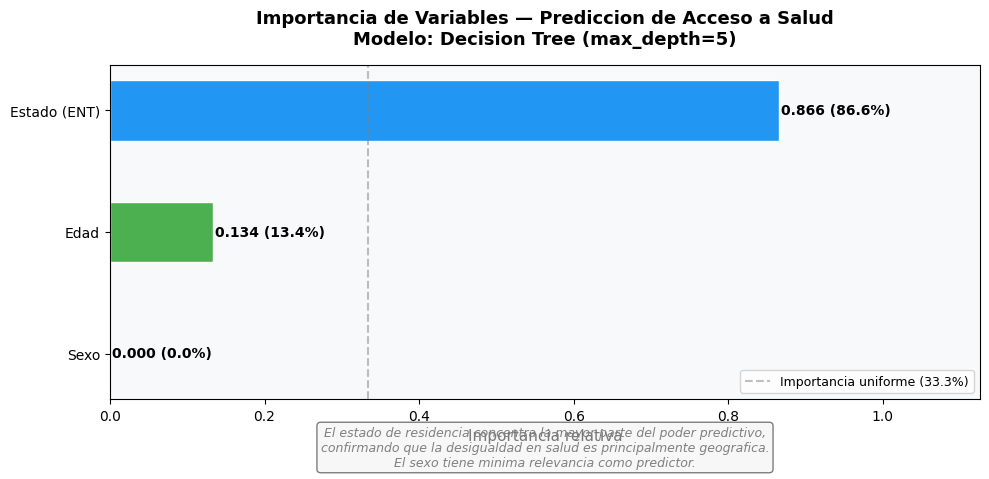

In [16]:
importancias = pd.DataFrame({
    'Variable': ['Estado (ENT)', 'Sexo', 'Edad'],
    'Importancia': modelo.feature_importances_
}).sort_values('Importancia', ascending=True)

print('--- Importancia de Variables ---')
print(importancias)

fig, ax = plt.subplots(figsize=(10, 5))

colores = ['#FF9800', '#4CAF50', '#2196F3']
bars = ax.barh(importancias['Variable'], importancias['Importancia'], 
               color=colores, height=0.5, edgecolor='white')

# Valores al final de cada barra
for i, v in enumerate(importancias['Importancia']):
    ax.text(v + 0.002, i, f'{v:.3f} ({v*100:.1f}%)', va='center', fontsize=10, fontweight='bold')

# Linea vertical de referencia
ax.axvline(x=1/3, color='gray', linestyle='--', alpha=0.5, label='Importancia uniforme (33.3%)')

# Fondo degradado por importancia
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

# Etiquetas y titulo
ax.set_title('Importancia de Variables — Prediccion de Acceso a Salud\nModelo: Decision Tree (max_depth=5)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Importancia relativa', fontsize=11)
ax.set_xlim(0, max(importancias['Importancia']) * 1.3)

# Leyenda
ax.legend(fontsize=9, loc='lower right')

# Anotacion interpretativa
ax.text(0.5, -0.2,
    'El estado de residencia concentra la mayor parte del poder predictivo,\n'
    'confirmando que la desigualdad en salud es principalmente geografica.\n'
    'El sexo tiene minima relevancia como predictor.',
    transform=ax.transAxes, ha='center', fontsize=9, 
    color='gray', style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.5))

plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
conn.close()
print('Conexion cerrada correctamente')

## 5. Conclusiones

A partir del análisis de la base de datos del Censo 2000 del INEGI con
10 millones de registros almacenados en SQL Server y procesados con
Apache Spark:

### Hallazgos principales:

1. **Acceso a salud**: El **65.6%** de la poblacion no tenia derechohabiencia
en el año 2000 — solo 1 de cada 3 mexicanos contaba con acceso formal
a servicios medicos.

2. **Brecha rural**: En zonas rurales, el **83.7%** de las personas no tenia
cobertura medica, comparado con zonas metropolitanas donde la proporcion
mejora significativamente.

3. **Brecha indigena**: La poblacion que habla lengua indigena presentaba
una tasa de desproteccion del **86.3%**, la mas alta de todos los grupos
analizados.

4. **Brecha educativa**: Las personas con licenciatura o posgrado son las
unicas donde la cobertura supera la desproteccion — la educacion actua
como principal factor protector del acceso a salud.

5. **Modelo predictivo**: El arbol de decision confirma con datos reales
que el **estado de residencia** explica el **86.6%** de la importancia
predictiva, la edad el **13.4%** y el sexo apenas el **0.02%**.

### Conclusion general:

La desigualdad en el acceso a servicios de salud en Mexico en el año 2000
estaba determinada casi exclusivamente por factores geograficos. El estado
de residencia concentra el 86.6% del poder predictivo del modelo, lo que
significa que nacer en ciertos estados practicamente determinaba si una
persona tendria o no acceso a servicios medicos formales. El sexo resulto
estadisticamente irrelevante como predictor, desmintiendo la hipotesis de
que la desigualdad en salud era principalmente una cuestion de genero.
Estos hallazgos fueron comprobados estadisticamente mediante la prueba
chi-cuadrado (p < 0.05) y el modelo de arbol de decision construido
con Scikit-learn sobre 10 millones de registros reales.